In [ ]:
from brian2 import *
%matplotlib inline

WARNING    C:\Users\emiel\AppData\Local\Temp\ipykernel_23852\3131378113.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend();
 [py.warnings]


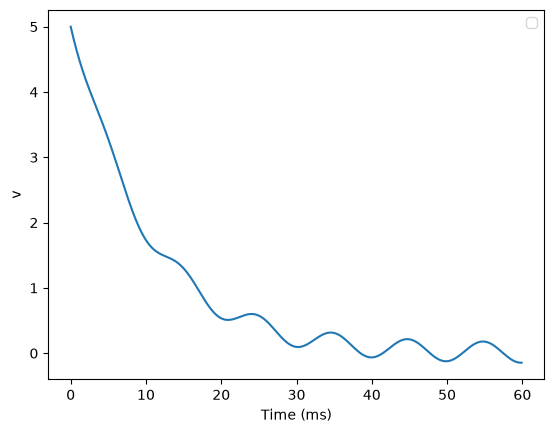

In [ ]:
# Intro
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (sin(2*pi*100*Hz*t)-v)/tau : 1
'''

G = NeuronGroup(
    N=1, 
    model=eqs,
    method="euler",
)

M = StateMonitor(
    source=G, 
    variables='v', 
    record=0,
)

G.v = 5

run(60*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v')
legend();

Spike times: [16.  32.1 48.2] ms


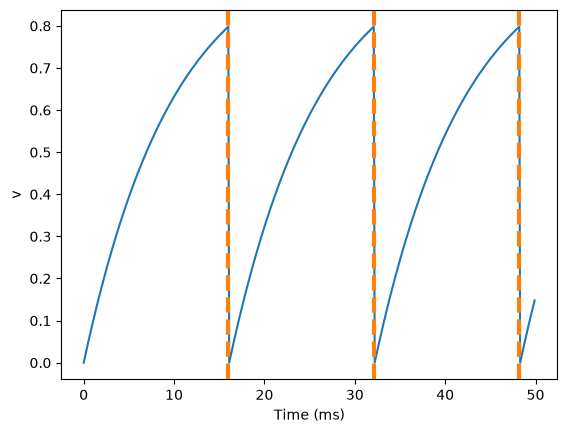

In [22]:
# Adding Spikes

start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(
    N=1,
    model=eqs,
    threshold='v>0.8',
    reset='v = 0',
    method='exact',
)

spikemon = SpikeMonitor(
    source=G,
)

statemon = StateMonitor(
    source=G,
    variables='v',
    record=0,
)

run(50*ms)

print('Spike times: %s' % spikemon.t[:])

plot(statemon.t/ms, statemon.v[0])
for t in spikemon.t:
    axvline(t/ms, ls='--', c='C1', lw=3)
xlabel('Time (ms)')
ylabel('v');

In [ ]:
# Refractoriness